In [1]:
import pandas as pd
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [9]:
# Load the Excel File
file_path = "/Users/jesslyngabriella/Desktop/Loan Data.xlsx"
df = pd.read_excel(file_path, sheet_name='Loans Data')

# Drop rows where "County" is missing
df_cleaned = df.dropna(subset=["County"])

# Sort by Loan Awards in descending order
df_sorted_awards = df_cleaned.sort_values("Loan Awards", ascending=False)

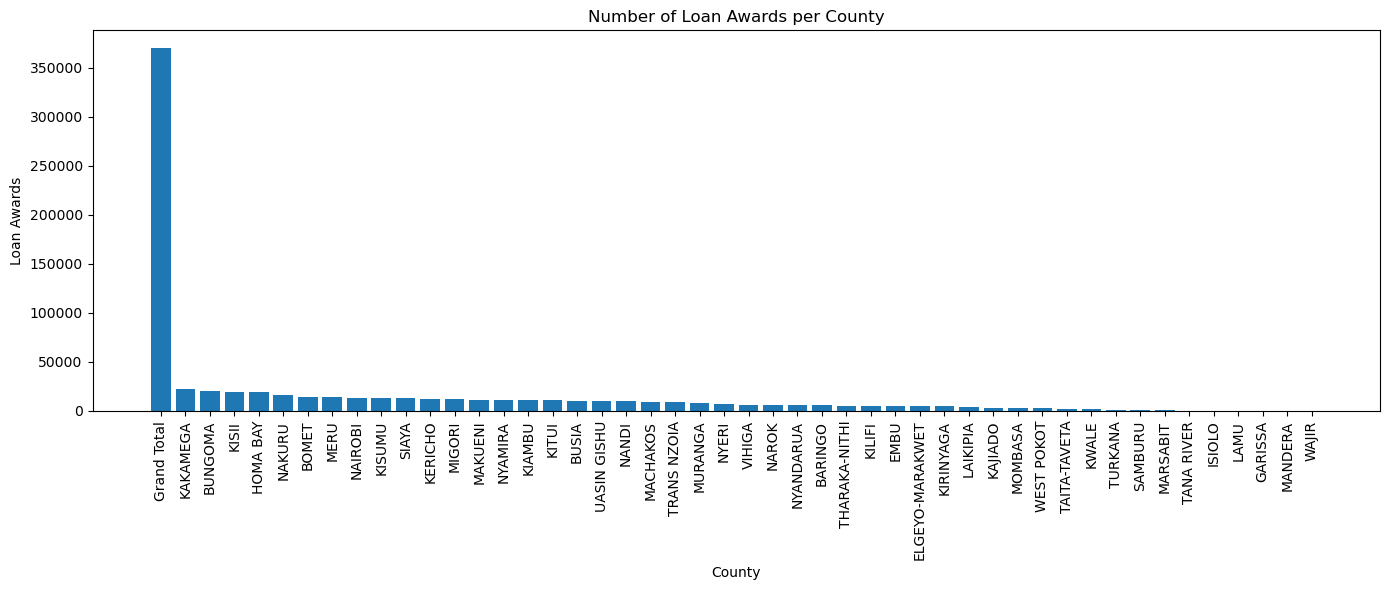

In [11]:
#Plot
plt.figure(figsize=(14, 6))
plt.bar(df_sorted_awards["County"], df_sorted_awards["Loan Awards"])
plt.xticks(rotation=90)
plt.title("Number of Loan Awards per County")
plt.xlabel("County")
plt.ylabel("Loan Awards")
plt.tight_layout()
plt.show()

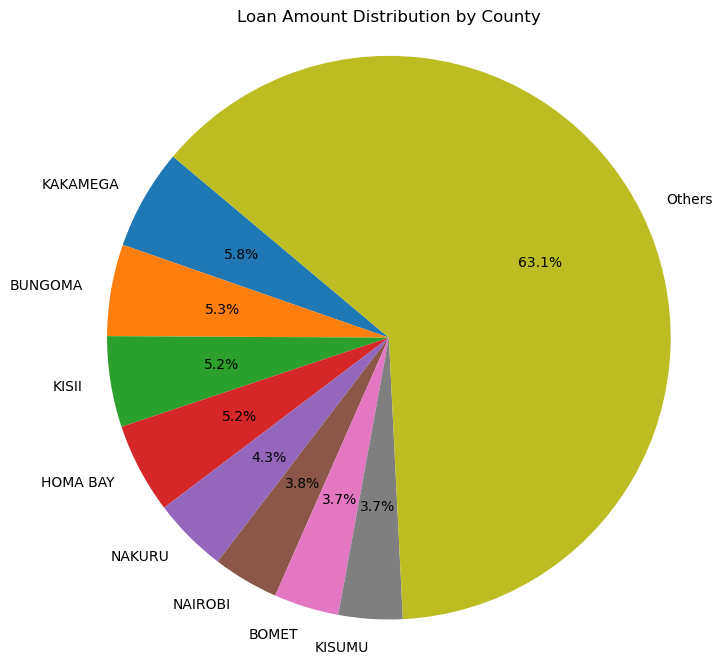

In [18]:
# Select top 8 counties and group rest as "Others"
top8 = df_cleaned.sort_values("Loan Amount", ascending=False).head(8)
others = pd.DataFrame({
    "County": ["Others"],
    "Loan Amount": [df_cleaned["Loan Amount"].sum() - top8["Loan Amount"].sum()]
})
pie_data = pd.concat([top8[["County", "Loan Amount"]], others])

# Plot
plt.figure(figsize=(8, 8))
plt.pie(
    pie_data["Loan Amount"],
    labels=pie_data["County"],
    autopct='%1.1f%%',
    startangle=140
)
plt.title("Loan Amount Distribution by County")
plt.axis('equal')
plt.show()

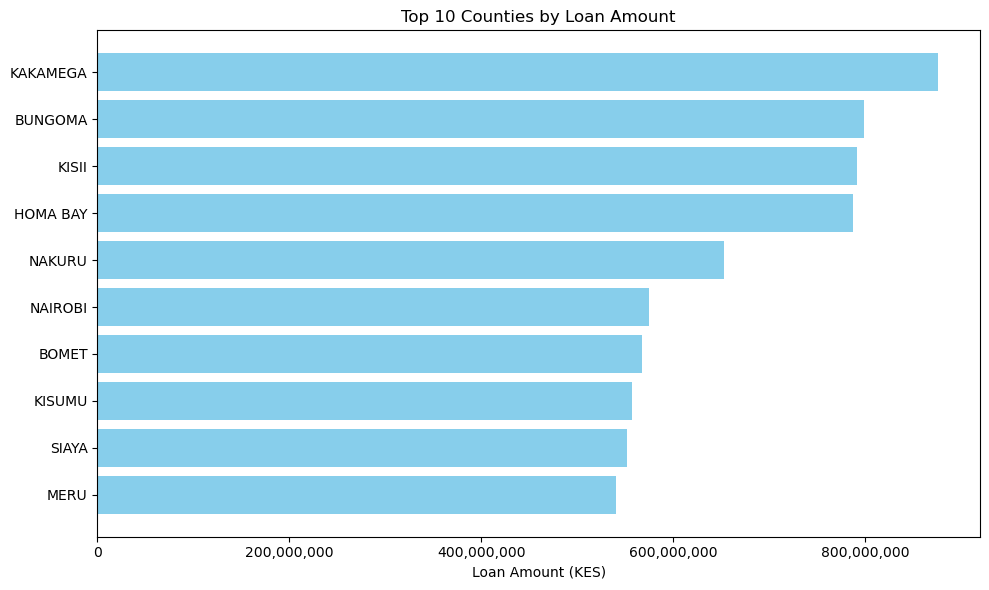

In [20]:
import matplotlib.ticker as ticker

# Sort and select top 10 loan amounts
top10_loan_amounts = df_cleaned.sort_values("Loan Amount", ascending=False).head(10)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(top10_loan_amounts["County"], top10_loan_amounts["Loan Amount"], color='skyblue')
plt.xlabel("Loan Amount (KES)")
plt.title("Top 10 Counties by Loan Amount")
plt.gca().invert_yaxis()

# Format x-axis with comma separators
formatter = ticker.FuncFormatter(lambda x, _: f'{x:,.0f}')
plt.gca().xaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()

Estimate future loan needs by county

In [27]:
df_cleaned_3 = df.dropna(subset=["County", "Loan Awards", "Loan Amount"]).copy()

In [29]:
# Loan amount per award
df_cleaned_3["Amount per Award"] = df_cleaned_3["Loan Amount"] / df_cleaned_3["Loan Awards"]

In [30]:
# Assuming 5% increase in loan awards next year per county

growth_rate = 0.05
df_cleaned_3["Projected Loan Awards"] = df_cleaned_3["Loan Awards"] * (1 + growth_rate)

In [31]:
# Estimate Future Loan Needs
df_cleaned_3["Projected Loan Amount"] = df_cleaned_3["Projected Loan Awards"] * df_cleaned_3["Amount per Award"]

In [34]:
# Top 10 counties by projected loan needs

df_cleaned_3_sorted = df_cleaned_3.sort_values("Projected Loan Amount", ascending=False)
top_10_projected = df_cleaned_3_sorted[["County", "Loan Awards", "Loan Amount", "Projected Loan Awards", "Projected Loan Amount"]].head(10)

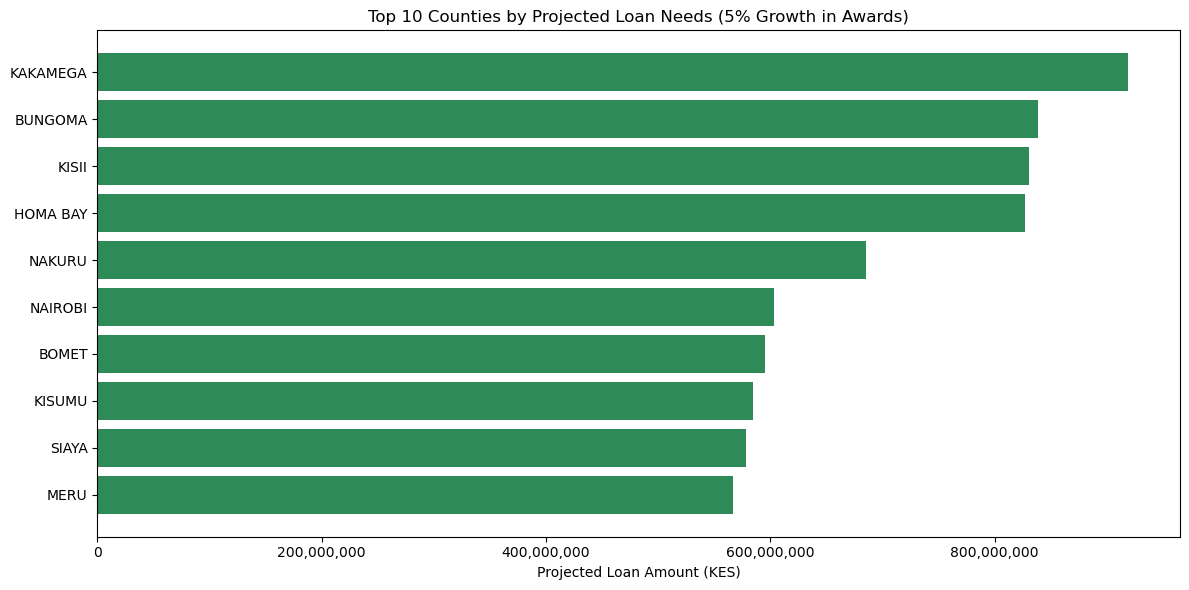

In [35]:
# Plot
plt.figure(figsize=(12, 6))
plt.barh(top_10_projected["County"], top_10_projected["Projected Loan Amount"], color="seagreen")
plt.xlabel("Projected Loan Amount (KES)")
plt.title("Top 10 Counties by Projected Loan Needs (5% Growth in Awards)")
plt.gca().invert_yaxis()

# Format x-axis with commas
formatter = ticker.FuncFormatter(lambda x, _: f'{x:,.0f}')
plt.gca().xaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()